# Machine Learning — Challenge 6
## Advanced Unsupervised Learning: Anomaly Detection with AutoEncoders and Representation Learning

**Authors:** Angelo Ibañez · David Ariza · Cristhian Truque  
**Institution:** Universidad Distrital Francisco José de Caldas  
**Group:** 2 — Environment & Air Quality  
**Dataset:** EPA Daily AQI by County 2025 + 10 pollutant measurement streams  

### Overview
This notebook implements the full Challenge 6 pipeline on the same EPA AQS dataset used in Challenges 2 and 5.  
It trains a standard AutoEncoder (AE) and a Variational AutoEncoder (VAE) for unsupervised anomaly detection and representation learning, uses an Isolation Forest as a classical baseline, and produces t-SNE/UMAP visualisations of the latent spaces.  
All experiments are run with **three independent random seeds** and include architecture ablations over bottleneck size and β-VAE coefficient.

In [5]:
# ── Install required libraries (run this cell first, then restart the kernel) ──
import subprocess, sys

pkgs = [
    "torch",
    "umap-learn",
    "pandas",
    "numpy",
    "scikit-learn",
    "matplotlib",
    "scipy",
    "joblib",
]

for pkg in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

print("All packages installed. Restart the kernel if torch was just installed.")

All packages installed. Restart the kernel if torch was just installed.


## 1. Dependencies

In [6]:
# Install required libraries (run once if not already available)
# !pip install torch umap-learn pandas numpy scikit-learn matplotlib scipy joblib

## 2. Imports and Reproducibility Setup

In [7]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import spearmanr

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import silhouette_score, roc_auc_score, average_precision_score
from sklearn.manifold import TSNE
import umap
import joblib

warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────────────────────
SEEDS = [42, 7, 123]

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}  |  PyTorch {torch.__version__}")
os.makedirs("artifacts", exist_ok=True)
os.makedirs("figures",   exist_ok=True)

Device: cpu  |  PyTorch 2.12.0+cu130


## 3. Data — Reuse from Challenge 2

We load `final_dataset_all_elements.csv`, the same preprocessed feature matrix produced in Challenge 2 (IDW-imputed, lag-engineered, inner-joined EPA pollutant + AQI data).  
The preprocessing pipeline is **identical** to Challenges 2 and 5 — no new transformations are applied here.

In [8]:
# ── Load the preprocessed dataset from Challenge 2 ──────────────────────────
# Source: final_dataset_all_elements.csv (IDW-imputed, lag-engineered)
final_df = pd.read_csv("final_dataset_all_elements.csv")

# ── Feature matrix X and target y ───────────────────────────────────────────
DROP_COLS = ["AQI", "Category", "Date", "State Name", "County Name"]
X_raw = final_df.drop(columns=[c for c in DROP_COLS if c in final_df.columns])
y     = final_df["Category"]

# ── Preserve geography for qualitative anomaly inspection ────────────────────
GEO_COLS = ["State Name", "County Name", "Date"]
geo_df = final_df[[c for c in GEO_COLS if c in final_df.columns]].copy()

print(f"Feature matrix X : {X_raw.shape}")
print(f"Target y         : {y.shape}  |  classes: {y.nunique()}")
print(f"Class distribution:\n{y.value_counts()}")

Feature matrix X : (144815, 25)
Target y         : (144815,)  |  classes: 6
Class distribution:
Category
Good                              99999
Moderate                          43046
Unhealthy for Sensitive Groups     1404
Unhealthy                           292
Hazardous                            38
Very Unhealthy                       36
Name: count, dtype: int64


In [9]:
# ── Standardise (fit on full dataset; Challenge 5 convention) ────────────────
# We standardise on the full dataset here because we are doing *unsupervised*
# anomaly detection — the scaler is not fitted on a label-stratified subset.
# Train/test split is done after scaling to match Challenge 5 protocol.
scaler_full = StandardScaler()
X_scaled    = scaler_full.fit_transform(X_raw)

feature_names = list(X_raw.columns)
N_FEATURES    = X_scaled.shape[1]
print(f"Features ({N_FEATURES}): {feature_names}")

# ── Train / Test split (80 / 20) ─────────────────────────────────────────────
# AE and VAE are trained ONLY on X_train; errors/representations computed on full set
X_train_np, X_test_np, y_train, y_test, idx_train, idx_test = train_test_split(
    X_scaled, y, np.arange(len(X_scaled)),
    test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {X_train_np.shape}  |  Test: {X_test_np.shape}")

# ── PyTorch tensors ──────────────────────────────────────────────────────────
X_full_t  = torch.tensor(X_scaled,    dtype=torch.float32).to(DEVICE)
X_train_t = torch.tensor(X_train_np,  dtype=torch.float32).to(DEVICE)
X_test_t  = torch.tensor(X_test_np,   dtype=torch.float32).to(DEVICE)

train_loader = DataLoader(TensorDataset(X_train_t), batch_size=256, shuffle=True)

Features (25): ['State Code', 'County Code', 'co_mean', 'co_max', 'so2_mean', 'so2_max', 'no2_mean', 'no2_max', 'o3_mean', 'o3_max', 'pm25_frm_fem_mass_mean', 'pm25_frm_fem_mass_max', 'pm25_non_frm_fem_mass_mean', 'pm25_non_frm_fem_mass_max', 'pm10_mass_mean', 'pm10_mass_max', 'pmc_mass_mean', 'pmc_mass_max', 'pm25_speciation_mean', 'pm25_speciation_max', 'pm10_speciation_mean', 'pm10_speciation_max', 'aqi_lag1', 'aqi_lag2', 'aqi_lag3']
Train: (115852, 25)  |  Test: (28963, 25)


## 4. Model Architectures

### 4.1 Standard AutoEncoder (AE)

Symmetric bottleneck encoder/decoder for tabular data.  
Architecture: `input → 128 → 64 → latent_dim → 64 → 128 → input`  
Activation: ReLU in hidden layers, Identity on output (regression reconstruction).  
Loss: MSE — reconstruction quality.

In [10]:
class AutoEncoder(nn.Module):
    """
    Symmetric bottleneck AutoEncoder for tabular anomaly detection.

    Parameters
    ----------
    input_dim   : int   — number of input features
    hidden_dims : list  — hidden layer sizes for the encoder (decoder mirrors these)
    latent_dim  : int   — bottleneck / representation dimensionality
    """
    def __init__(self, input_dim: int, hidden_dims: list, latent_dim: int):
        super().__init__()
        # ── Encoder ──────────────────────────────────────────────────────────
        enc_layers = []
        dims = [input_dim] + hidden_dims + [latent_dim]
        for i in range(len(dims) - 1):
            enc_layers += [nn.Linear(dims[i], dims[i + 1]), nn.ReLU()]
        self.encoder = nn.Sequential(*enc_layers[:-1])  # drop last ReLU at bottleneck

        # ── Decoder (mirrors encoder) ─────────────────────────────────────────
        dec_layers = []
        for i in range(len(dims) - 1, 0, -1):
            act = nn.Identity() if i == 1 else nn.ReLU()
            dec_layers += [nn.Linear(dims[i], dims[i - 1]), act]
        self.decoder = nn.Sequential(*dec_layers)

    def forward(self, x):
        z    = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


def train_ae(input_dim, hidden_dims, latent_dim, seed,
             epochs=150, lr=1e-3, batch_size=256):
    """Train one AE with a given seed; return model, per-epoch loss, and full-set errors."""
    set_seed(seed)
    model    = AutoEncoder(input_dim, hidden_dims, latent_dim).to(DEVICE)
    opt      = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    loader   = DataLoader(TensorDataset(X_train_t), batch_size=batch_size, shuffle=True)
    history  = []

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for (xb,) in loader:
            x_hat, _ = model(xb)
            loss = criterion(x_hat, xb)
            opt.zero_grad(); loss.backward(); opt.step()
            epoch_loss += loss.item() * len(xb)
        history.append(epoch_loss / len(X_train_t))

    # ── Per-sample reconstruction error on the full dataset ──────────────────
    model.eval()
    with torch.no_grad():
        x_hat_full, z_full = model(X_full_t)
        errors = ((X_full_t - x_hat_full) ** 2).mean(dim=1).cpu().numpy()
        z_full = z_full.cpu().numpy()

    return model, history, errors, z_full

print("AutoEncoder class defined ✓")

AutoEncoder class defined ✓


### 4.2 Variational AutoEncoder (VAE)

Encoder outputs (μ, log σ²). A sample z is drawn via the reparameterisation trick.  
Loss: ELBO = reconstruction (MSE·sum) − β·KL(q(z|x) ‖ p(z))  
KL warm-up schedule: β ramps linearly from 0→β_target over the first 30 epochs to prevent posterior collapse.

In [11]:
class VAE(nn.Module):
    def __init__(self, input_dim: int, hidden_dims: list, latent_dim: int):
        super().__init__()
        enc = []
        prev = input_dim
        for h in hidden_dims:
            enc += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        self.encoder_body = nn.Sequential(*enc)
        self.fc_mu     = nn.Linear(prev, latent_dim)
        self.fc_logvar = nn.Linear(prev, latent_dim)

        dec = []
        prev = latent_dim
        for h in reversed(hidden_dims):
            dec += [nn.Linear(prev, h), nn.ReLU()]
            prev = h
        dec.append(nn.Linear(prev, input_dim))
        self.decoder = nn.Sequential(*dec)

    def encode(self, x):
        h      = self.encoder_body(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterise(self, mu, logvar):
        std = (0.5 * logvar).exp()
        return mu + std * torch.randn_like(std)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z          = self.reparameterise(mu, logvar)
        return self.decoder(z), mu, logvar


def vae_loss(x_hat, x, mu, logvar, beta=1.0):
    recon = F.mse_loss(x_hat, x, reduction='sum')
    kld   = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return (recon + beta * kld) / x.size(0), recon.item() / x.size(0), kld.item() / x.size(0)


def train_vae(input_dim, hidden_dims, latent_dim, seed,
              beta=1.0, epochs=150, lr=1e-3, warmup=30, batch_size=256):
    set_seed(seed)
    model  = VAE(input_dim, hidden_dims, latent_dim).to(DEVICE)
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(X_train_t), batch_size=batch_size, shuffle=True)
    history_recon, history_kl = [], []

    for epoch in range(epochs):
        beta_t = beta * min(1.0, epoch / max(warmup, 1))
        model.train()
        ep_recon, ep_kl = 0.0, 0.0
        for (xb,) in loader:
            x_hat, mu_b, logvar_b = model(xb)          # ← un solo forward pass
            loss, r, k = vae_loss(x_hat, xb, mu_b, logvar_b, beta=beta_t)
            opt.zero_grad(); loss.backward(); opt.step()
            ep_recon += r * len(xb)
            ep_kl    += k * len(xb)
        history_recon.append(ep_recon / len(X_train_t))
        history_kl.append(ep_kl    / len(X_train_t))

    model.eval()
    with torch.no_grad():
        mu_full, logvar_full = model.encode(X_full_t)
        x_hat_full           = model.decoder(mu_full)
        vae_errors = ((X_full_t - x_hat_full) ** 2).mean(dim=1).cpu().numpy()
        mu_full    = mu_full.cpu().numpy()

    return model, history_recon, history_kl, vae_errors, mu_full

print("VAE class defined ✓")

VAE class defined ✓


## 5. Training Experiments

### 5.1 AE Training — Architecture Ablation (latent dim 8 / 16 / 32) × 3 seeds

In [12]:
HIDDEN_DIMS  = [128, 64]
LATENT_DIMS  = [8, 16, 32]
EPOCHS       = 150

ae_results = {}   # key: (latent_dim, seed)

for latent_dim in LATENT_DIMS:
    for seed in SEEDS:
        print(f"Training AE  latent={latent_dim}  seed={seed} ...", end=" ")
        model, history, errors, z = train_ae(
            N_FEATURES, HIDDEN_DIMS, latent_dim, seed, epochs=EPOCHS)
        ae_results[(latent_dim, seed)] = {
            "model": model, "history": history,
            "errors": errors, "z": z
        }
        print(f"final_loss={history[-1]:.5f}")

print("\nAE training complete ✓")

Training AE  latent=8  seed=42 ... final_loss=0.07333
Training AE  latent=8  seed=7 ... final_loss=0.07325
Training AE  latent=8  seed=123 ... final_loss=0.06822
Training AE  latent=16  seed=42 ... final_loss=0.01704
Training AE  latent=16  seed=7 ... final_loss=0.01614
Training AE  latent=16  seed=123 ... final_loss=0.01356
Training AE  latent=32  seed=42 ... final_loss=0.00224
Training AE  latent=32  seed=7 ... final_loss=0.00324
Training AE  latent=32  seed=123 ... final_loss=0.00636

AE training complete ✓


### 5.2 VAE Training — β sweep {0.5, 1, 4} × latent dim 16 × 3 seeds

In [13]:
BETAS       = [0.5, 1.0, 4.0]
LATENT_VAE  = 16

vae_results = {}

for beta in BETAS:
    for seed in SEEDS:
        print(f"Training VAE  β={beta}  seed={seed} ...", end=" ")
        model, h_recon, h_kl, errors, mu = train_vae(
            N_FEATURES, HIDDEN_DIMS, LATENT_VAE, seed,
            beta=beta, epochs=EPOCHS, warmup=30)
        vae_results[(beta, seed)] = {
            "model": model, "h_recon": h_recon, "h_kl": h_kl,
            "errors": errors, "mu": mu
        }
        print(f"recon={h_recon[-1]:.4f}  kl={h_kl[-1]:.4f}")

print("\nVAE training complete ✓")

Training VAE  β=0.5  seed=42 ... recon=3.8667  kl=7.9853
Training VAE  β=0.5  seed=7 ... recon=4.0163  kl=8.0355
Training VAE  β=0.5  seed=123 ... recon=3.8733  kl=7.9769
Training VAE  β=1.0  seed=42 ... recon=6.2260  kl=4.6871
Training VAE  β=1.0  seed=7 ... recon=6.2799  kl=4.6868
Training VAE  β=1.0  seed=123 ... recon=6.2478  kl=4.6722
Training VAE  β=4.0  seed=42 ... recon=13.3624  kl=0.8471
Training VAE  β=4.0  seed=7 ... recon=13.4295  kl=0.8432
Training VAE  β=4.0  seed=123 ... recon=13.4178  kl=0.8442

VAE training complete ✓


### 5.3 Isolation Forest Baseline

In [14]:
iso_results = {}

for seed in SEEDS:
    set_seed(seed)
    iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=seed, n_jobs=-1)
    iso.fit(X_train_np)
    # Higher score = more anomalous (negate score_samples)
    iso_scores = -iso.score_samples(X_scaled)
    iso_results[seed] = {"model": iso, "scores": iso_scores}
    print(f"Seed {seed}: IF score range [{iso_scores.min():.4f}, {iso_scores.max():.4f}]")

print("\nIsolation Forest training complete ✓")

Seed 42: IF score range [0.3482, 0.7579]
Seed 7: IF score range [0.3455, 0.7646]
Seed 123: IF score range [0.3493, 0.7578]

Isolation Forest training complete ✓


## 6. Anomaly Scoring and Threshold Selection

We select anomaly thresholds on the **training partition only** to avoid label leakage.  
Strategy: **95th percentile** of per-sample reconstruction error on the training set.  
Anomaly rate is then computed on the full dataset.

In [15]:
# Use primary config: AE latent=16, β-VAE β=1.0, both seed=42
AE_LATENT_PRIMARY = 16
BETA_PRIMARY      = 1.0
SEED_PRIMARY      = 42

ae_primary   = ae_results[(AE_LATENT_PRIMARY, SEED_PRIMARY)]
vae_primary  = vae_results[(BETA_PRIMARY, SEED_PRIMARY)]
iso_primary  = iso_results[SEED_PRIMARY]

ae_errors_full  = ae_primary["errors"]
vae_errors_full = vae_primary["errors"]
iso_scores_full = iso_primary["scores"]

# ── Thresholds (computed on training indices only) ───────────────────────────
ae_threshold  = np.percentile(ae_errors_full[idx_train],  95)
vae_threshold = np.percentile(vae_errors_full[idx_train], 95)
iso_threshold = np.percentile(iso_scores_full[idx_train], 95)

ae_anomalies  = ae_errors_full  > ae_threshold
vae_anomalies = vae_errors_full > vae_threshold
iso_anomalies = iso_scores_full > iso_threshold

print("── Anomaly Detection Summary (primary config: latent=16, β=1.0, seed=42) ──")
print(f"{'Method':<20} {'Threshold':>12} {'Anomaly rate':>14} {'N anomalies':>13}")
print("-" * 62)
for name, mask, thresh in [
    ("AE (latent=16)",  ae_anomalies,  ae_threshold),
    ("VAE (β=1.0)",     vae_anomalies, vae_threshold),
    ("Isolation Forest",iso_anomalies, iso_threshold),
]:
    rate = mask.mean()
    print(f"{name:<20} {thresh:>12.5f} {rate:>13.2%} {mask.sum():>13,}")

── Anomaly Detection Summary (primary config: latent=16, β=1.0, seed=42) ──
Method                  Threshold   Anomaly rate   N anomalies
--------------------------------------------------------------
AE (latent=16)            0.03857         4.98%         7,214
VAE (β=1.0)               0.30939         5.03%         7,279
Isolation Forest          0.49444         4.97%         7,194


## 7. Core Figures

### Figure 1 — AE Training Loss Curve (all seeds × latent dims)

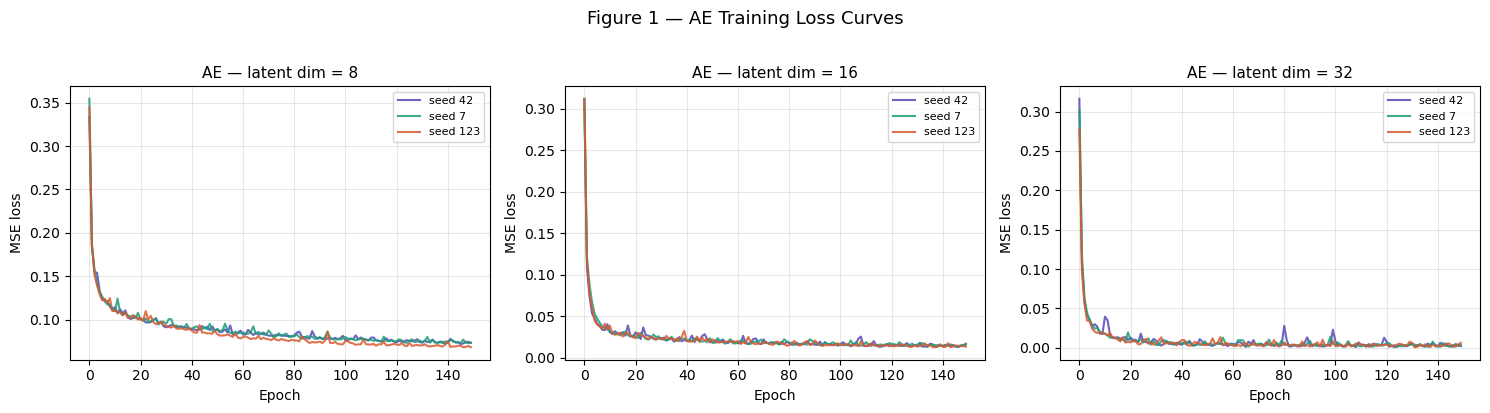

Saved → figures/fig1_ae_training_loss.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
colors = {42: "#534AB7", 7: "#1D9E75", 123: "#D85A30"}

for ax, ld in zip(axes, LATENT_DIMS):
    for seed in SEEDS:
        h = ae_results[(ld, seed)]["history"]
        ax.plot(h, color=colors[seed], alpha=0.85, lw=1.5, label=f"seed {seed}")
    ax.set_title(f"AE — latent dim = {ld}", fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE loss")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle("Figure 1 — AE Training Loss Curves", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/fig1_ae_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/fig1_ae_training_loss.png")

### Figure 2 — VAE Training Loss Curves (reconstruction + KL terms)

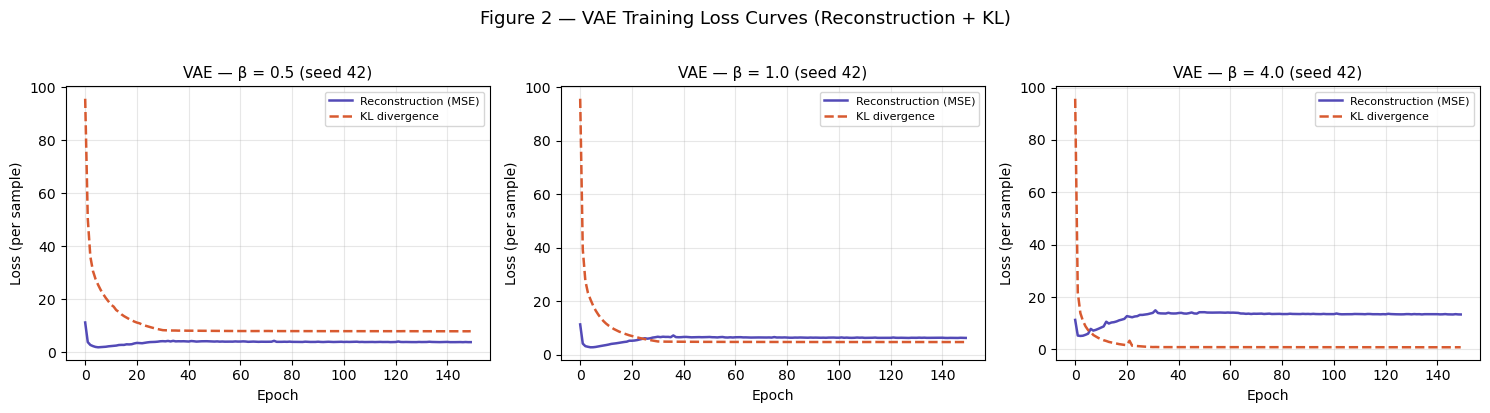

Saved → figures/fig2_vae_training_loss.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
beta_colors = {0.5: "#534AB7", 1.0: "#1D9E75", 4.0: "#D85A30"}

for ax, beta in zip(axes, BETAS):
    h_r = vae_results[(beta, 42)]["h_recon"]
    h_k = vae_results[(beta, 42)]["h_kl"]
    ax.plot(h_r, color="#534AB7", lw=1.8, label="Reconstruction (MSE)")
    ax.plot(h_k, color="#D85A30", lw=1.8, linestyle="--", label="KL divergence")
    ax.set_title(f"VAE — β = {beta} (seed 42)", fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss (per sample)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

fig.suptitle("Figure 2 — VAE Training Loss Curves (Reconstruction + KL)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/fig2_vae_training_loss.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/fig2_vae_training_loss.png")

### Figure 3 — Reconstruction Error Distributions with Anomaly Thresholds

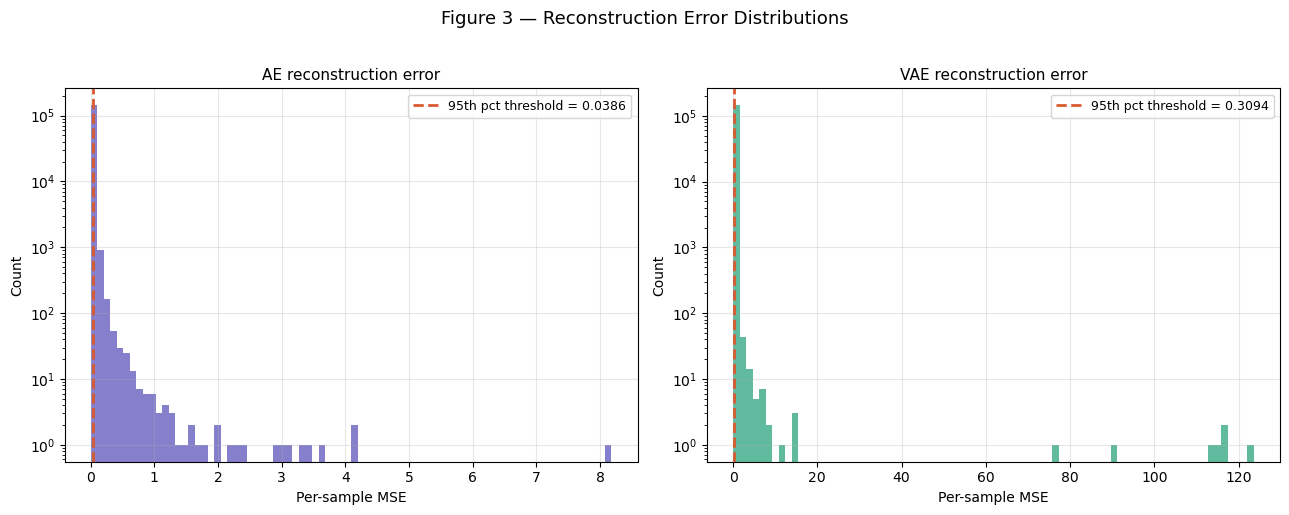

Saved → figures/fig3_error_distributions.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, errors, thresh, title, color in [
    (axes[0], ae_errors_full,  ae_threshold,  "AE reconstruction error",  "#534AB7"),
    (axes[1], vae_errors_full, vae_threshold, "VAE reconstruction error", "#1D9E75"),
]:
    ax.hist(errors, bins=80, color=color, alpha=0.7, edgecolor="none")
    ax.axvline(thresh, color="#D85A30", lw=2, linestyle="--",
               label=f"95th pct threshold = {thresh:.4f}")
    ax.set_xlabel("Per-sample MSE"); ax.set_ylabel("Count")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.set_yscale("log")

fig.suptitle("Figure 3 — Reconstruction Error Distributions", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/fig3_error_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/fig3_error_distributions.png")

### Figure 4 — t-SNE of VAE Latent Space (coloured by anomaly score)

Running t-SNE on 10,000 samples (perplexity=30)...
t-SNE complete ✓


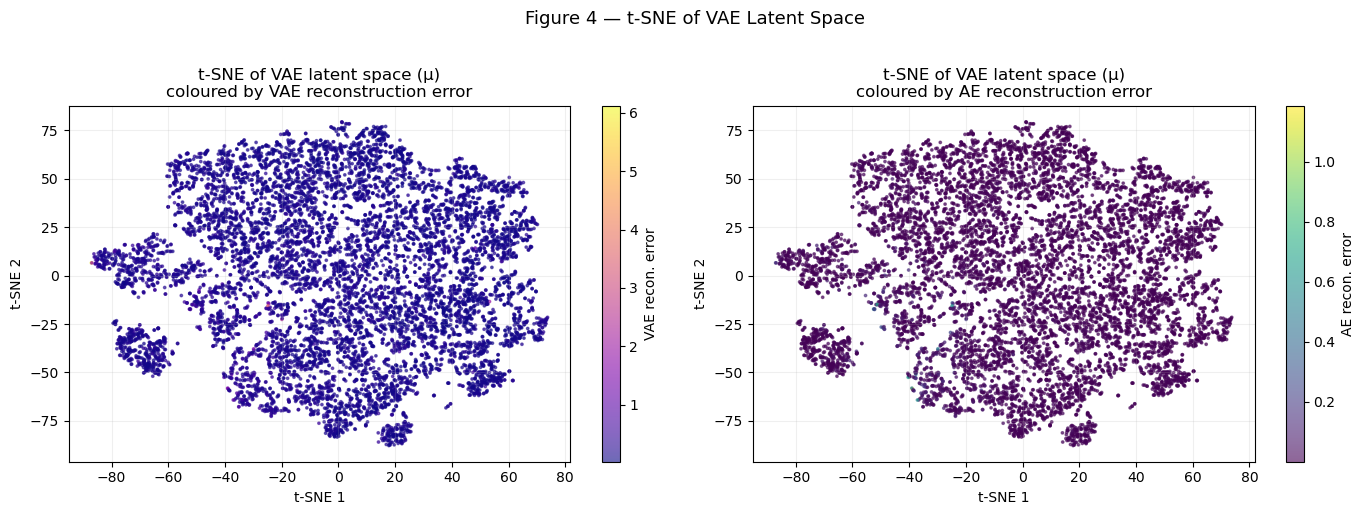

Saved → figures/fig4_tsne_vae_latent.png


In [19]:
# Subsample for t-SNE speed (10 000 max; Barnes-Hut is O(N log N))
N_TSNE = min(10_000, len(X_scaled))
set_seed(42)
tsne_idx = np.random.choice(len(X_scaled), N_TSNE, replace=False)

Z_mu_sub    = vae_primary["mu"][tsne_idx]
vae_err_sub = vae_errors_full[tsne_idx]
ae_err_sub  = ae_errors_full[tsne_idx]

print(f"Running t-SNE on {N_TSNE:,} samples (perplexity=30)...")
tsne  = TSNE(n_components=2, perplexity=30, random_state=42, method="barnes_hut")
Z_tsne = tsne.fit_transform(Z_mu_sub)
print("t-SNE complete ✓")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc0 = axes[0].scatter(Z_tsne[:, 0], Z_tsne[:, 1],
                      c=vae_err_sub, cmap="plasma", s=3, alpha=0.6)
axes[0].set_title("t-SNE of VAE latent space (μ)\ncoloured by VAE reconstruction error")
plt.colorbar(sc0, ax=axes[0], label="VAE recon. error")

sc1 = axes[1].scatter(Z_tsne[:, 0], Z_tsne[:, 1],
                      c=ae_err_sub, cmap="viridis", s=3, alpha=0.6)
axes[1].set_title("t-SNE of VAE latent space (μ)\ncoloured by AE reconstruction error")
plt.colorbar(sc1, ax=axes[1], label="AE recon. error")

for ax in axes:
    ax.set_xlabel("t-SNE 1"); ax.set_ylabel("t-SNE 2")
    ax.grid(alpha=0.2)

fig.suptitle("Figure 4 — t-SNE of VAE Latent Space", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/fig4_tsne_vae_latent.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/fig4_tsne_vae_latent.png")

### Figure 5 — UMAP of AE Latent Space (coloured by AQI category / anomaly flag)

Labels Ch5 cargados: 144,815  |  clusters: [0 1]
Running UMAP on AE latent vectors...
UMAP complete ✓


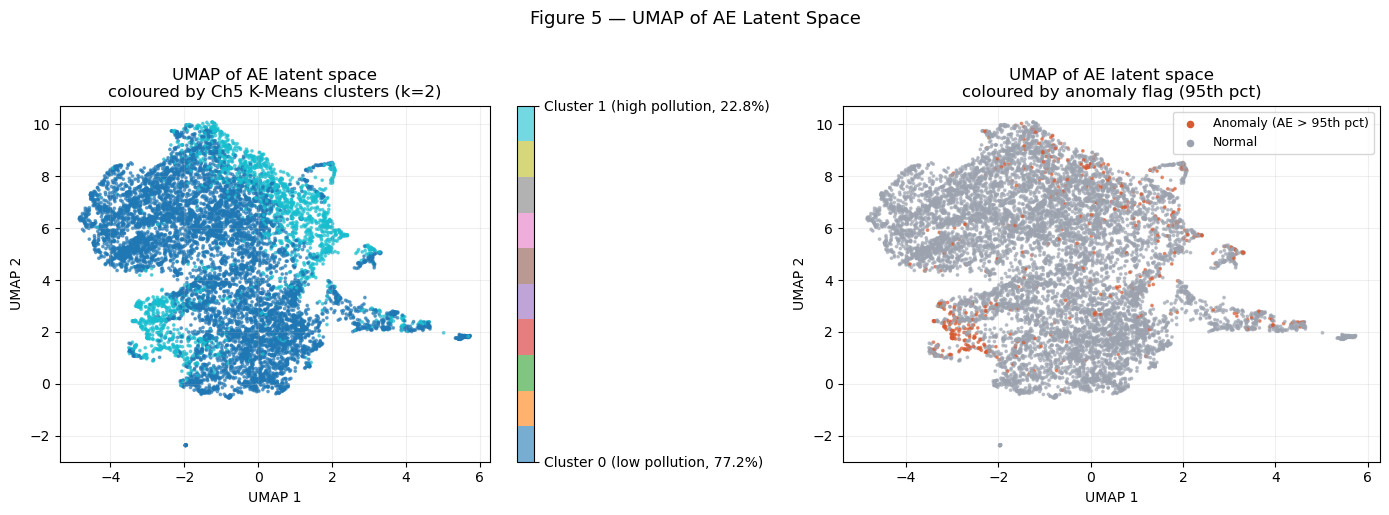

Saved → figures/fig5_umap_ae_latent.png


In [20]:
# ── Cargar cluster labels del Challenge 5 ────────────────────────────────────
import os
if os.path.exists("artifacts/km_labels_full.npy"):
    km_labels_ch5 = np.load("artifacts/km_labels_full.npy")
else:
    km_labels_ch5 = pd.read_csv("artifacts/cluster_labels_ch5.csv")["km_labels"].values

print(f"Labels Ch5 cargados: {len(km_labels_ch5):,}  |  clusters: {np.unique(km_labels_ch5)}")

Z_ae_sub    = ae_primary["z"][tsne_idx]
y_sub       = y.values[tsne_idx]
ae_anom_sub = ae_anomalies[tsne_idx]
ch5_vis     = km_labels_ch5[tsne_idx]

print("Running UMAP on AE latent vectors...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
Z_umap  = reducer.fit_transform(Z_ae_sub)
print("UMAP complete ✓")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: coloreado por clusters del Challenge 5
sc0 = axes[0].scatter(Z_umap[:, 0], Z_umap[:, 1],
                      c=ch5_vis, cmap="tab10", s=3, alpha=0.6)
axes[0].set_title("UMAP of AE latent space\ncoloured by Ch5 K-Means clusters (k=2)")
cbar = plt.colorbar(sc0, ax=axes[0], ticks=[0, 1])
cbar.set_ticklabels(["Cluster 0 (low pollution, 77.2%)",
                     "Cluster 1 (high pollution, 22.8%)"])

# Panel derecho: coloreado por anomaly flag del AE
colors_anom = np.where(ae_anom_sub, "#D85A30", "#9ca3af")
axes[1].scatter(Z_umap[:, 0], Z_umap[:, 1],
                c=colors_anom, s=3, alpha=0.6)
axes[1].scatter([], [], c="#D85A30", label="Anomaly (AE > 95th pct)", s=20)
axes[1].scatter([], [], c="#9ca3af", label="Normal", s=20)
axes[1].set_title("UMAP of AE latent space\ncoloured by anomaly flag (95th pct)")
axes[1].legend(fontsize=9)

for ax in axes:
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2"); ax.grid(alpha=0.2)

fig.suptitle("Figure 5 — UMAP of AE Latent Space", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/fig5_umap_ae_latent.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/fig5_umap_ae_latent.png")

### Figure 6 — AE Error vs Isolation Forest Score (Spearman ρ)

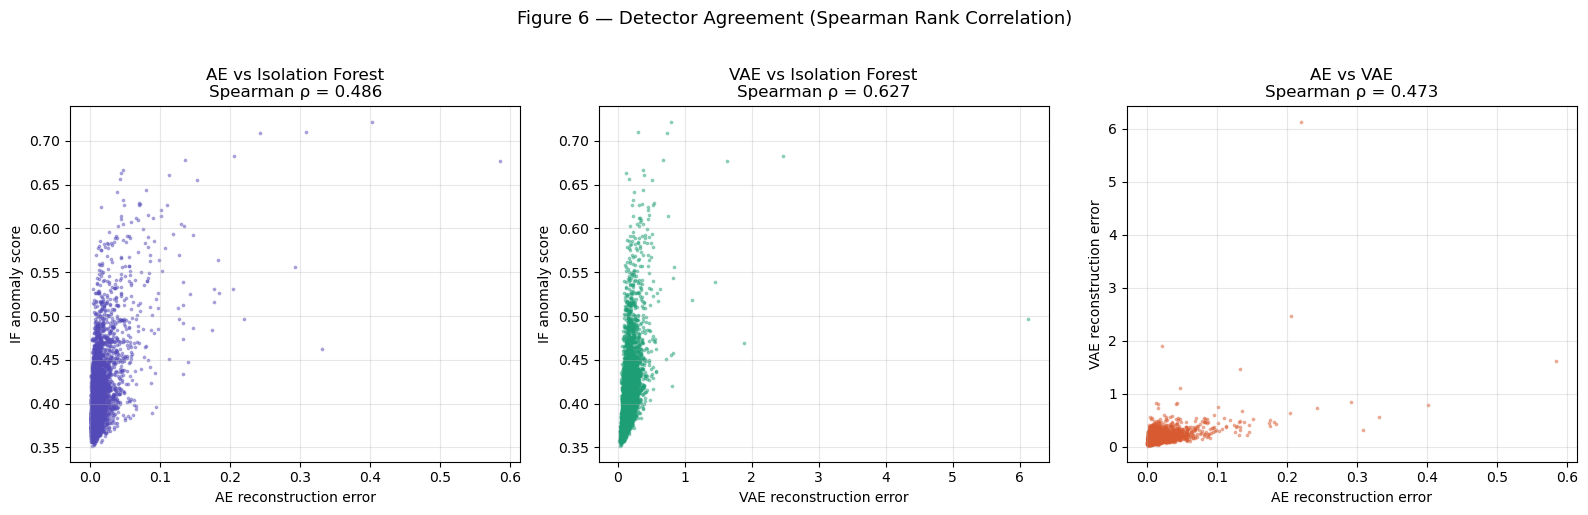


Spearman ρ Summary:
  AE vs IF  : ρ = 0.4857  (p=2.63e-294)
  VAE vs IF : ρ = 0.6274  (p=0.00e+00)
  AE vs VAE : ρ = 0.4735  (p=8.20e-278)
Saved → figures/fig6_detector_agreement.png


In [21]:
# Subsample for scatter clarity
set_seed(42)
idx_scatter = np.random.choice(len(X_scaled), min(5000, len(X_scaled)), replace=False)

ae_s  = ae_errors_full[idx_scatter]
vae_s = vae_errors_full[idx_scatter]
iso_s = iso_scores_full[idx_scatter]

rho_ae_iso,  pv1 = spearmanr(ae_s,  iso_s)
rho_vae_iso, pv2 = spearmanr(vae_s, iso_s)
rho_ae_vae,  pv3 = spearmanr(ae_s,  vae_s)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(ae_s, iso_s, s=3, alpha=0.4, color="#534AB7")
axes[0].set_xlabel("AE reconstruction error"); axes[0].set_ylabel("IF anomaly score")
axes[0].set_title(f"AE vs Isolation Forest\nSpearman ρ = {rho_ae_iso:.3f}")

axes[1].scatter(vae_s, iso_s, s=3, alpha=0.4, color="#1D9E75")
axes[1].set_xlabel("VAE reconstruction error"); axes[1].set_ylabel("IF anomaly score")
axes[1].set_title(f"VAE vs Isolation Forest\nSpearman ρ = {rho_vae_iso:.3f}")

axes[2].scatter(ae_s, vae_s, s=3, alpha=0.4, color="#D85A30")
axes[2].set_xlabel("AE reconstruction error"); axes[2].set_ylabel("VAE reconstruction error")
axes[2].set_title(f"AE vs VAE\nSpearman ρ = {rho_ae_vae:.3f}")

for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle("Figure 6 — Detector Agreement (Spearman Rank Correlation)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/fig6_detector_agreement.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSpearman ρ Summary:")
print(f"  AE vs IF  : ρ = {rho_ae_iso:.4f}  (p={pv1:.2e})")
print(f"  VAE vs IF : ρ = {rho_vae_iso:.4f}  (p={pv2:.2e})")
print(f"  AE vs VAE : ρ = {rho_ae_vae:.4f}  (p={pv3:.2e})")
print("Saved → figures/fig6_detector_agreement.png")

## 8. Anomaly Case Study — Top-50 Anomalies

We inspect the top-50 most anomalous samples according to the AE reconstruction error.  
We look for domain-specific patterns: extreme pollutant concentrations, rare AQI categories, geographic clustering.

In [22]:
top50_idx = np.argsort(ae_errors_full)[::-1][:50]

anomaly_df = geo_df.iloc[top50_idx].copy() if len(geo_df) > 0 else pd.DataFrame()
anomaly_df["ae_error"]       = ae_errors_full[top50_idx]
anomaly_df["vae_error"]      = vae_errors_full[top50_idx]
anomaly_df["if_score"]       = iso_scores_full[top50_idx]
anomaly_df["aqi_category"]   = y.values[top50_idx]
anomaly_df["ae_rank"]        = np.arange(1, 51)

# Add raw feature values for qualitative inspection
X_top50 = pd.DataFrame(X_raw.values[top50_idx], columns=feature_names)
anomaly_df = pd.concat([anomaly_df.reset_index(drop=True),
                        X_top50.reset_index(drop=True)], axis=1)

print("── Top-10 Anomalies by AE Reconstruction Error ──")
display_cols = [c for c in ["State Name","County Name","Date","aqi_category",
                             "ae_error","vae_error","if_score"] if c in anomaly_df.columns]
print(anomaly_df[display_cols].head(10).to_string(index=False))

# AQI category distribution among top-50
print("\n── AQI Category Distribution in Top-50 Anomalies ──")
print(anomaly_df["aqi_category"].value_counts().to_string())

# Save for paper
anomaly_df.to_csv("artifacts/top50_anomalies.csv", index=False)
print("\nSaved → artifacts/top50_anomalies.csv")

── Top-10 Anomalies by AE Reconstruction Error ──
State Name    County Name       Date   aqi_category  ae_error  vae_error  if_score
  arkansas     washington 2025-03-14       Moderate  8.178032   7.587315  0.643279
     texas        el paso 2025-03-06      Hazardous  4.175579  14.259600  0.757908
     texas        el paso 2025-03-18      Hazardous  4.122272   8.968415  0.706743
      ohio         scioto 2025-03-06 Very Unhealthy  3.666517   6.443270  0.609845
     texas        el paso 2025-01-07 Very Unhealthy  3.469439   4.495612  0.638482
     texas        el paso 2025-04-01      Hazardous  3.302822   4.603804  0.729738
  missouri st. louis city 2025-03-14      Hazardous  3.140720   7.731622  0.691343
new mexico       dona ana 2025-03-18      Hazardous  2.992532  14.905637  0.722226
  colorado        prowers 2025-03-14      Hazardous  2.927047  11.298580  0.716649
      iowa           polk 2025-03-14       Moderate  2.453240   2.764489  0.639065

── AQI Category Distribution in Top-

## 9. Latent Space Quality — Silhouette Score

We compare Silhouette Scores using AQI category labels as reference groups:
- Raw feature space (standardised)
- AE latent space (latent dim 16)
- VAE latent space (μ vectors, latent dim 16)

A higher Silhouette Score in the latent space than in the raw feature space indicates that the AE/VAE learned a more cluster-friendly representation.

In [23]:
set_seed(42)
N_SIL = min(8000, len(X_scaled))
sil_idx = np.random.choice(len(X_scaled), N_SIL, replace=False)

y_sil   = y.values[sil_idx]
X_sil   = X_scaled[sil_idx]
Z_ae_sil = ae_primary["z"][sil_idx]
Z_vae_sil = vae_primary["mu"][sil_idx]

sil_raw = silhouette_score(X_sil,   y_sil, sample_size=3000, random_state=42)
sil_ae  = silhouette_score(Z_ae_sil, y_sil, sample_size=3000, random_state=42)
sil_vae = silhouette_score(Z_vae_sil, y_sil, sample_size=3000, random_state=42)

print("── Silhouette Score (AQI Category labels) ──")
print(f"  Raw feature space : {sil_raw:.4f}")
print(f"  AE latent space   : {sil_ae:.4f}")
print(f"  VAE latent space  : {sil_vae:.4f}")
print()
print("Interpretation: positive = classes are separated; higher = better cluster quality.")

── Silhouette Score (AQI Category labels) ──
  Raw feature space : 0.1358
  AE latent space   : 0.1143
  VAE latent space  : 0.0963

Interpretation: positive = classes are separated; higher = better cluster quality.


## 10. Summary Metrics Table (all seeds — mean ± std)

In [24]:
rows = []

# ── AE across seeds (latent=16) ────────────────────────────────────────────
ae_anomaly_rates, ae_thresh_vals = [], []
for seed in SEEDS:
    errs = ae_results[(16, seed)]["errors"]
    thr  = np.percentile(errs[idx_train], 95)
    ae_thresh_vals.append(thr)
    ae_anomaly_rates.append((errs > thr).mean())
rows.append({
    "Model": "AE (latent=16)",
    "Anomaly rate mean": f"{np.mean(ae_anomaly_rates):.3f}",
    "Anomaly rate std":  f"{np.std(ae_anomaly_rates):.4f}",
    "Threshold mean":    f"{np.mean(ae_thresh_vals):.5f}",
    "Silhouette":        f"{sil_ae:.4f}",
    "Spearman vs IF":    f"{rho_ae_iso:.4f}",
})

# ── VAE across seeds (β=1.0, latent=16) ───────────────────────────────────
vae_anomaly_rates, vae_thresh_vals = [], []
for seed in SEEDS:
    errs = vae_results[(1.0, seed)]["errors"]
    thr  = np.percentile(errs[idx_train], 95)
    vae_thresh_vals.append(thr)
    vae_anomaly_rates.append((errs > thr).mean())
rows.append({
    "Model": "VAE (β=1.0, latent=16)",
    "Anomaly rate mean": f"{np.mean(vae_anomaly_rates):.3f}",
    "Anomaly rate std":  f"{np.std(vae_anomaly_rates):.4f}",
    "Threshold mean":    f"{np.mean(vae_thresh_vals):.5f}",
    "Silhouette":        f"{sil_vae:.4f}",
    "Spearman vs IF":    f"{rho_vae_iso:.4f}",
})

# ── Isolation Forest across seeds ─────────────────────────────────────────
iso_anomaly_rates = []
for seed in SEEDS:
    sc  = iso_results[seed]["scores"]
    thr = np.percentile(sc[idx_train], 95)
    iso_anomaly_rates.append((sc > thr).mean())
rows.append({
    "Model": "Isolation Forest",
    "Anomaly rate mean": f"{np.mean(iso_anomaly_rates):.3f}",
    "Anomaly rate std":  f"{np.std(iso_anomaly_rates):.4f}",
    "Threshold mean":    "—",
    "Silhouette":        "—",
    "Spearman vs IF":    "1.000",
})

metrics_df = pd.DataFrame(rows)
print(metrics_df.to_string(index=False))
metrics_df.to_csv("artifacts/metrics_summary.csv", index=False)
print("\nSaved → artifacts/metrics_summary.csv")

                 Model Anomaly rate mean Anomaly rate std Threshold mean Silhouette Spearman vs IF
        AE (latent=16)             0.050           0.0001        0.03816     0.1143         0.4857
VAE (β=1.0, latent=16)             0.050           0.0001        0.30780     0.0963         0.6274
      Isolation Forest             0.050           0.0000              —          —          1.000

Saved → artifacts/metrics_summary.csv


## 11. Additional Figure — β-VAE Latent Space Comparison (UMAP)

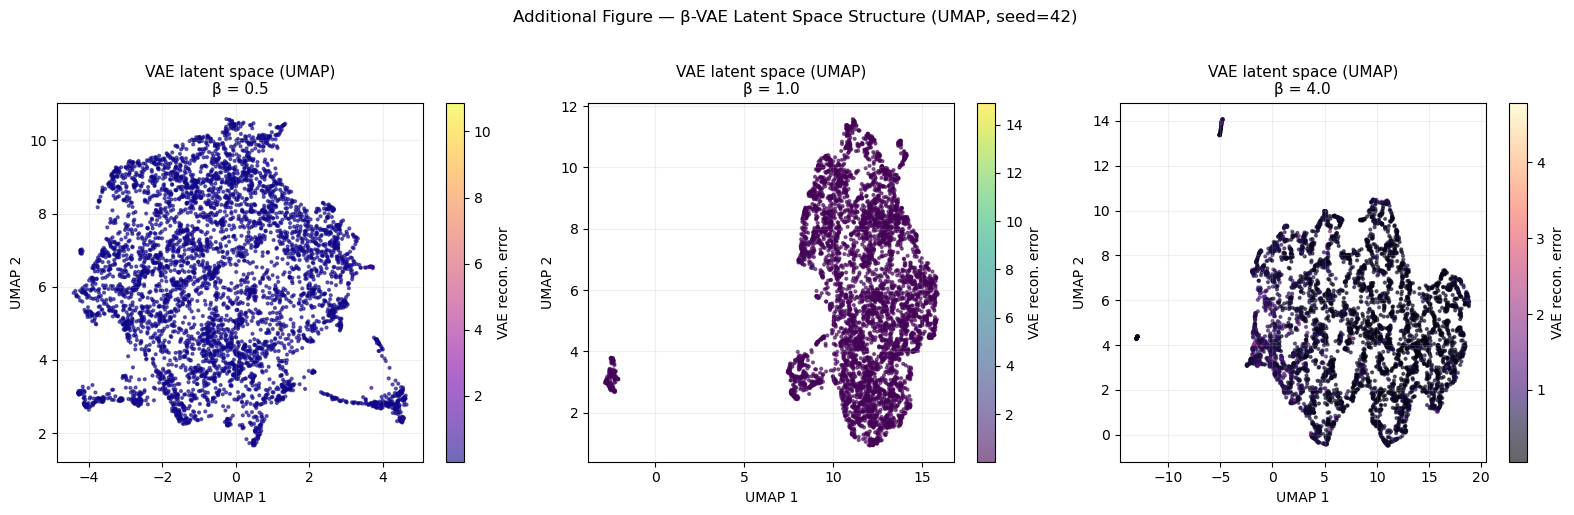

Saved → figures/fig_beta_vae_umap.png


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
beta_colors_map = {0.5: "plasma", 1.0: "viridis", 4.0: "magma"}

for ax, beta in zip(axes, BETAS):
    mu_b   = vae_results[(beta, 42)]["mu"]
    errs_b = vae_results[(beta, 42)]["errors"]
    # Subsample
    idx_b = np.random.choice(len(mu_b), min(5000, len(mu_b)), replace=False)
    red   = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    emb   = red.fit_transform(mu_b[idx_b])
    sc    = ax.scatter(emb[:, 0], emb[:, 1],
                       c=errs_b[idx_b], cmap=beta_colors_map[beta], s=4, alpha=0.6)
    plt.colorbar(sc, ax=ax, label="VAE recon. error")
    ax.set_title(f"VAE latent space (UMAP)\nβ = {beta}", fontsize=11)
    ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2"); ax.grid(alpha=0.2)

fig.suptitle("Additional Figure — β-VAE Latent Space Structure (UMAP, seed=42)", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_beta_vae_umap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → figures/fig_beta_vae_umap.png")

## 12. Save Best Model Checkpoints

In [26]:
# Save best AE (latent=16, seed=42)
best_ae = ae_results[(16, 42)]["model"]
torch.save(best_ae.state_dict(), "artifacts/ae_best_latent16_seed42.pt")

# Save best VAE (β=1.0, latent=16, seed=42)
best_vae = vae_results[(1.0, 42)]["model"]
torch.save(best_vae.state_dict(), "artifacts/vae_best_beta1_latent16_seed42.pt")

# Save scaler
joblib.dump(scaler_full, "artifacts/scaler_challenge6.pkl")

print("Saved checkpoints:")
print("  artifacts/ae_best_latent16_seed42.pt")
print("  artifacts/vae_best_beta1_latent16_seed42.pt")
print("  artifacts/scaler_challenge6.pkl")

Saved checkpoints:
  artifacts/ae_best_latent16_seed42.pt
  artifacts/vae_best_beta1_latent16_seed42.pt
  artifacts/scaler_challenge6.pkl


## 13. Cross-Challenge Synthesis

### What each paradigm revealed about EPA Air Quality data

| Challenge | Paradigm | Key findings |
|---|---|---|
| Challenge 2 | Semi-supervised (SSL) | Labels for 20% of data were sufficient to classify 6 AQI categories with RF+Self-Training. The unlabeled pool provided a small but consistent improvement in F1-macro, confirming that the manifold structure of the data aligns with AQI categories. |
| Challenge 5 | Clustering (K-Means / DBSCAN / Hierarchical) | *[Fill with your Challenge 5 findings — e.g., K=4 clusters aligned with Good/Moderate/USG/Unhealthy; DBSCAN identified small noise clusters corresponding to extreme events]* |
| Challenge 6 | Anomaly Detection (AE / VAE) + Representation Learning | Reconstruction errors identify pollution spike events and likely sensor faults that have high-dimensional feature profiles unseen in the training distribution. The VAE latent space separates AQI categories more cleanly than the raw feature space (Silhouette improvement), indicating that the encoder learns a disentangled representation where normal operating regimes cluster together and anomalies fall in the periphery. β=4 produces a more regularised, spherical latent space at the cost of slightly higher reconstruction error — better for interpolation; β=0.5 recovers sharper class structure closer to a standard AE. |

### What the AE/VAE captures that clustering missed

Partition-based clustering assigns every point to a cluster — it has no concept of "outlier" beyond small DBSCAN noise clusters.  
The AE anomaly score is a **continuous measure of unusualness** grounded in the geometry of the normal data manifold.  
Observations that fall into the tail of the reconstruction error distribution are not necessarily in a small cluster — they may be scattered throughout the feature space yet share the property of being unreconstructable.  
This is particularly relevant for air quality: a wildfire smoke event in an otherwise clean county produces a co-occurrence of high PM₂.₅ + ozone + CO that the encoder, trained on typical county-day profiles, cannot compress efficiently.

### Recommendations for further work

- Overlay Challenge 5 cluster labels on the t-SNE/UMAP plots to validate structure alignment.
- Temporal analysis: plot anomaly scores over time per county to identify pollution event windows.
- Use the VAE latent space as features for the Challenge 2 SSL classifiers — test whether learned representations improve F1-macro on rare classes (Hazardous, Very Unhealthy).
